# 06 · Label-Quality Estimation

Estimates per-sample reliability of the model-predicted MRKR labels using a
confident-learning approach. A model trained on radiologist-labeled data produces
predicted probabilities for MRKR; the probability assigned to each given label
serves as its quality score. Scores are written to disk and consumed during
training (configurations D, E) to down-weight unreliable samples.

## Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import sys, importlib
sys.path.insert(0,'/content/drive/MyDrive/Master Thesis/scope3')
import config; importlib.reload(config)
import pandas as pd, numpy as np
from pathlib import Path
import torch
if 'training_lib' in sys.modules: importlib.reload(sys.modules['training_lib'])
import training_lib as T
if not torch.cuda.is_available(): raise RuntimeError('No GPU. Runtime -> Change runtime type -> GPU.')
print('GPU:', torch.cuda.get_device_name(0))
manifest = T.prepare_local_data()
print(f'Manifest: {len(manifest):,} rows')

Mounted at /content/drive
GPU: NVIDIA A100-SXM4-40GB
Copied array in 32s
Loaded array (61558, 224, 224) in 1s
Manifest: 61,558 rows


## Train estimator on radiologist data, score MRKR

In [3]:
import time
clean=manifest[manifest['dataset'].isin(['oai','nhanes3'])].reset_index(drop=True)
noisy=manifest[manifest['dataset']=='mrkr'].reset_index(drop=True)
print(f'Clean: {len(clean):,}  Noisy(MRKR): {len(noisy):,}')

mech={'sampler':True,'noise_loss':False,'curriculum':False,'domain_adv':False,'hierarchical':True,'ordinal':False,'use_quality':False}
va=clean.sample(frac=0.15,random_state=0); tr=clean.drop(va.index)
_e=config.EPOCHS; config.EPOCHS=10
T.run_training('quality_estimator_seed0', tr.reset_index(drop=True), va.reset_index(drop=True),
               va.reset_index(drop=True), mech, 0, config.CKPT_DIR, config.RESULTS_DIR, log_fn=print)
config.EPOCHS=_e

model=T.HierarchicalNet(config.NUM_CLASSES).to('cuda')
T.load_ckpt(str(config.CKPT_DIR/'quality_estimator_seed0_best.pt'), model, None)
preds,probs=T.predict_tta(model,noisy,'cuda',use_tta=False)
given=noisy['kl_grade'].values
pq=probs[np.arange(len(given)),given]
out=noisy.copy(); out['label_quality']=pq; out['model_agrees']=(preds==given)
out.to_csv(str(config.RESULTS_DIR/'mrkr_label_quality.csv'),index=False)
print(f'Agreement: {(preds==given).mean():.1%}, mean quality: {pq.mean():.3f}')
print('Saved: mrkr_label_quality.csv (consumed by configs D, E)')

Clean: 13,332  Noisy(MRKR): 39,967
Downloading: "https://download.pytorch.org/models/convnext_large-ea097f82.pth" to /root/.cache/torch/hub/checkpoints/convnext_large-ea097f82.pth


100%|██████████| 755M/755M [00:03<00:00, 242MB/s]


  [quality_estimator_seed0] ep1/10 loss=1.790 tr=0.414 val=0.454 gap=-0.040 qwk=0.073 grl=0.00 (43s)
  [quality_estimator_seed0] ep2/10 loss=1.674 tr=0.450 val=0.481 gap=-0.031 qwk=0.222 grl=0.00 (27s)
  [quality_estimator_seed0] ep3/10 loss=1.598 tr=0.487 val=0.501 gap=-0.014 qwk=0.341 grl=0.00 (26s)
  [quality_estimator_seed0] ep4/10 loss=1.558 tr=0.495 val=0.521 gap=-0.026 qwk=0.452 grl=0.00 (26s)
  [quality_estimator_seed0] ep5/10 loss=1.515 tr=0.513 val=0.517 gap=-0.004 qwk=0.418 grl=0.00 (26s)
  [quality_estimator_seed0] ep6/10 loss=1.491 tr=0.519 val=0.534 gap=-0.015 qwk=0.493 grl=0.00 (26s)
  [quality_estimator_seed0] ep7/10 loss=1.463 tr=0.523 val=0.539 gap=-0.016 qwk=0.515 grl=0.00 (26s)
  [quality_estimator_seed0] ep8/10 loss=1.441 tr=0.533 val=0.539 gap=-0.006 qwk=0.509 grl=0.00 (26s)
  [quality_estimator_seed0] ep9/10 loss=1.444 tr=0.533 val=0.544 gap=-0.011 qwk=0.521 grl=0.00 (26s)
  [quality_estimator_seed0] ep10/10 loss=1.430 tr=0.541 val=0.543 gap=-0.003 qwk=0.519 grl=

## Quality distribution

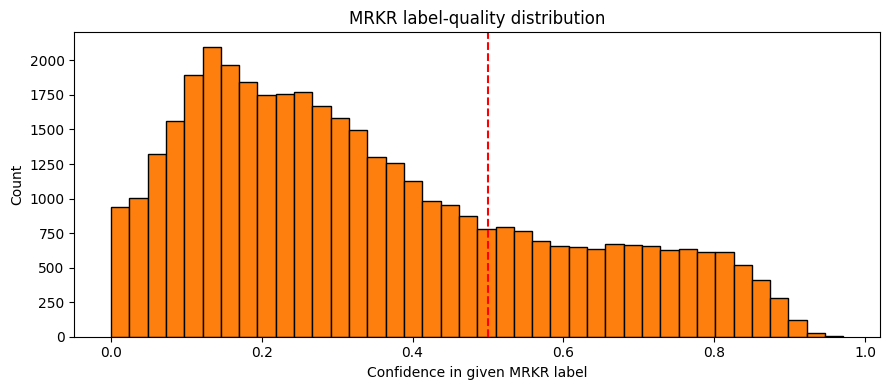

13,026 samples below 0.2 confidence (down-weighted to floor).


In [4]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(9,4))
ax.hist(pq,bins=40,color='tab:orange',edgecolor='black'); ax.axvline(0.5,color='red',ls='--')
ax.set_xlabel('Confidence in given MRKR label'); ax.set_ylabel('Count')
ax.set_title('MRKR label-quality distribution')
plt.tight_layout(); plt.savefig(str(config.RESULTS_DIR/'label_quality_hist.png'),dpi=130,bbox_inches='tight'); plt.show()
print(f'{int((pq<0.2).sum()):,} samples below 0.2 confidence (down-weighted to floor).')